# Olist E-Commerce Case Study

## About the Dataset

This project uses the Brazilian E-Commerce Public Dataset by Olist.
The dataset contains approximately 100,000 orders made between 2016 and 2018 across multiple marketplaces in Brazil.

It includes information related to orders, customers, products, sellers, payments, logistics and customer reviews,
allowing analysis from multiple perspectives such as sales performance, delivery times and customer satisfaction.

The data is real commercial data, fully anonymized for public use.
    
## Analysis Questions

The main questions this analysis aims to answer are:

1. How have sales evolved over time?
2. Which product categories generate the most revenue?
3. Are there significant differences in sales between states?
4. What is the average delivery time of orders?
5. What proportion of orders are delivered late?
6. Is there a relationship between delivery delays and review scores?

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
#Import Data
customers=pd.read_csv('../Data/olist_customers_dataset.csv')
geolocation=pd.read_csv('../Data/olist_geolocation_dataset.csv')
order_items=pd.read_csv('../Data/olist_order_items_dataset.csv')
order_payments=pd.read_csv('../Data/olist_order_payments_dataset.csv')
order_reviews=pd.read_csv('../Data/olist_order_reviews_dataset.csv')
orders=pd.read_csv('../Data/olist_orders_dataset.csv')
products=pd.read_csv('../Data/olist_products_dataset.csv')
sellers=pd.read_csv('../Data/olist_sellers_dataset.csv')
translation=pd.read_csv('../Data/product_category_name_translation.csv')

## 1. Product Category Analysis
To understand the business core, I first need to identify which products drive the most revenue. Since the original dataset is in Portuguese, this section involves translating the categories and cleaning the data to ensure an accurate ranking.

**Key Objectives:**
* Harmonize category names using English translations.
* Handle missing values and untranslated categories.
* Identify the Top 10 categories by total sales.


In [3]:
# Check total unique categories in products (excluding NaNs)
print(f"Unique categories in products: {products['product_category_name'].nunique()}")

# Check for products without any assigned category
print(f"Products with missing category name: {products['product_category_name'].isna().sum()}")

# Check total unique translations available
print(f"Unique translations available: {translation['product_category_name_english'].nunique()}")



Unique categories in products: 73
Products with missing category name: 610
Unique translations available: 71


In [4]:
#We merge the product dataset with the English translations. For the missing values in the English column, we fallback to the original Portuguese names. Finally, 
#we handle any remaining nulls as 'Unknown', format the text to Title Case, and retain only the necessary columns.

products_translated = pd.merge(products, translation, on='product_category_name', how='left')

products_translated['product_category_name_english'] = (
    products_translated['product_category_name_english']
    .fillna(products_translated['product_category_name']) 
    .fillna('Unknown')                                   
    .str.replace('_', ' ')                               
    .str.title()                                         
)

products_clean = products_translated[['product_id', 'product_category_name_english']]



We can now use the products_clean table to identify the top-selling categories. To do this, we will merge it with the order_items table, group the data by category, and calculate the total revenue by summing the prices.

In [5]:
# Left merge to bring translated category names into sales data
sales_products = pd.merge(order_items, products_clean, on='product_id', how='left')

# Group by category and sum prices to calculate revenue per category
category_revenue = sales_products.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)

# Convert to DataFrame and select the top 10 categories
top_10_categories = category_revenue.head(10).reset_index()

# Rename columns for clarity
top_10_categories.columns = ['Category', 'Total Revenue']

print("Top 10 Categories by Revenue:")
print(top_10_categories)

Top 10 Categories by Revenue:
                Category  Total Revenue
0          Health Beauty     1258681.34
1          Watches Gifts     1205005.68
2         Bed Bath Table     1036988.68
3         Sports Leisure      988048.97
4  Computers Accessories      911954.32
5        Furniture Decor      729762.49
6             Cool Stuff      635290.85
7             Housewares      632248.66
8                   Auto      592720.11
9           Garden Tools      485256.46


Top Revenue Drivers: The "Health Beauty" and "Watches Gifts" categories are the primary revenue drivers for Olist, both exceeding R$ 1.2M in total sales.

Market Diversity: The Top 10 categories represent a wide range of consumer interests, from essential home goods (Bed Bath Table, Housewares) to discretionary spending (Cool Stuff, Auto).

---
## 2. Sales Evolution Over Time
After identifying the top-performing categories, the next step is to understand the business's growth trajectory. 
In this section, I will analyze how sales have evolved from 2016 to 2018. 

**Key Objectives:**
* Identify the overall sales trend.
* Detect seasonal peaks.
* Determine if the revenue is consistent month-over-month.

In [6]:
# We merge orders and order_items to link timestamps with prices
# This creates our base for time-series analysis
sales_time = pd.merge(orders[['order_id', 'order_purchase_timestamp']], 
                      order_items[['order_id', 'price']], 
                      on='order_id', 
                      how='inner')

# Convert the timestamp to datetime objects
sales_time['order_purchase_timestamp'] = pd.to_datetime(sales_time['order_purchase_timestamp'])

sales_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 3 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  112650 non-null  object        
 1   order_purchase_timestamp  112650 non-null  datetime64[ns]
 2   price                     112650 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 2.6+ MB


In [7]:
monthly_revenue = sales_time.set_index('order_purchase_timestamp')['price'].resample('MS').sum().reset_index()
monthly_revenue.head()


,order_purchase_timestamp,price
0,2016-09-01,267.36
1,2016-10-01,49507.66
2,2016-11-01,0.00
3,2016-12-01,10.90
4,2017-01-01,120312.87


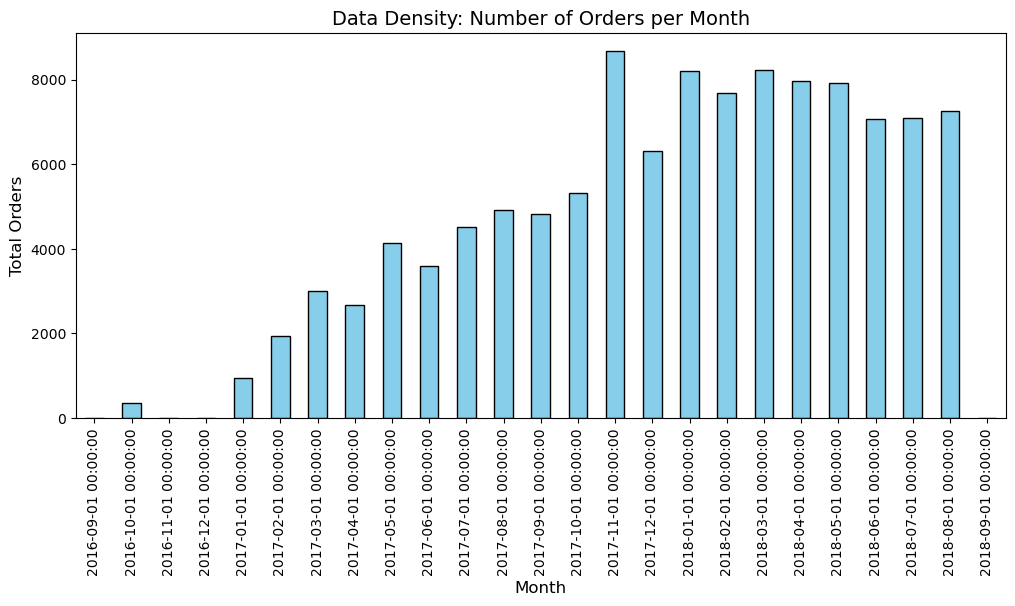

In [8]:
# We are going to find the number of orders per month to see if the data is consistent.

order_counts = sales_time.groupby(pd.Grouper(key='order_purchase_timestamp', freq='MS')).size()

plt.figure(figsize=(12, 5))
order_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Data Density: Number of Orders per Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Orders', fontsize=12) 
plt.show()

The data density per month shows that 2016 contains only sporadic early stage data and the last month (September 2018) is incomplete. I will focus on the period from January 2017 to August 2018, where de data is consistent.

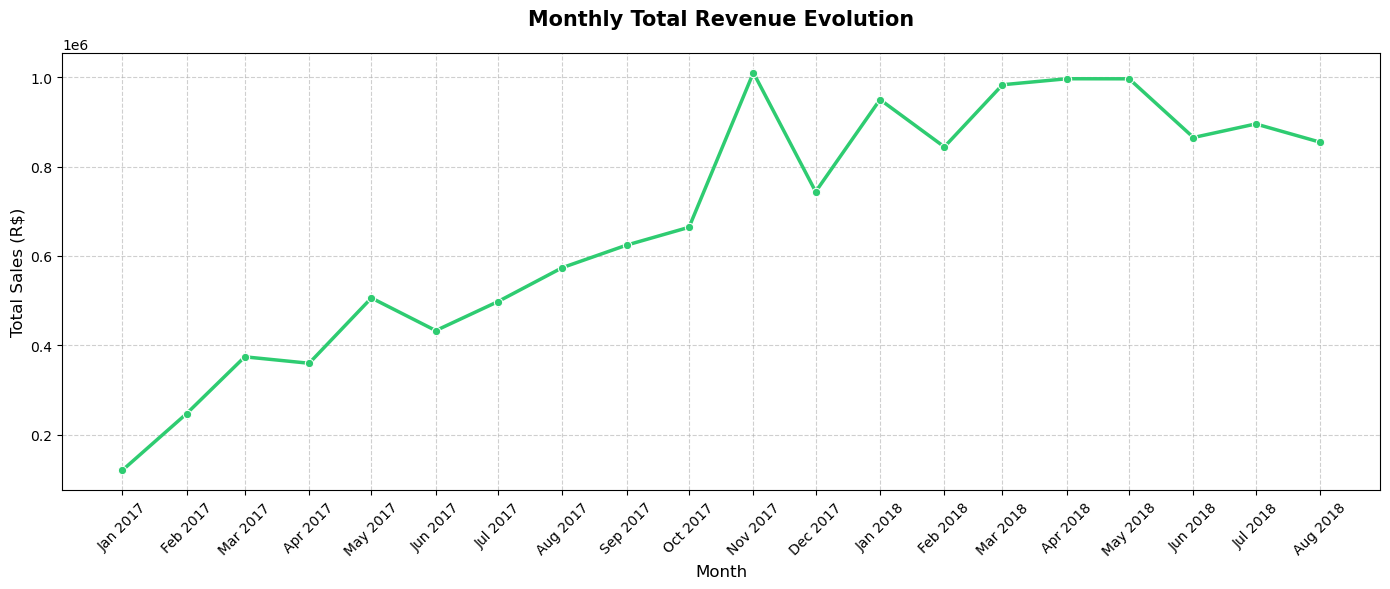

In [9]:
monthly_revenue = monthly_revenue[
    (monthly_revenue['order_purchase_timestamp'] >= '2017-01-01') & 
    (monthly_revenue['order_purchase_timestamp'] < '2018-09-01')
    ]

plt.figure(figsize=(14, 6))

ax = sns.lineplot(data=monthly_revenue, x='order_purchase_timestamp', y='price', 
                  marker='o', color='#2ecc71', linewidth=2.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.title('Monthly Total Revenue Evolution', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


We observe a upward trend during the year 2017 with a significant spike in November 2017. After the November peak, sales stabilized at a much higher baseline.

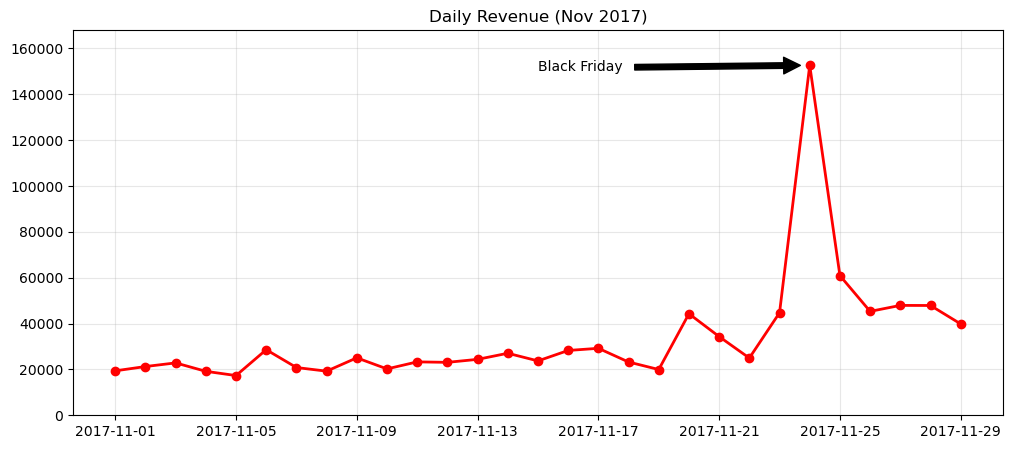

In [10]:
# Filter Nov 2017 sales and group by day.
nov_2017 = sales_time[(sales_time['order_purchase_timestamp'] >= '2017-11-01') & 
                      (sales_time['order_purchase_timestamp'] <= '2017-11-30')]

daily_nov = nov_2017.groupby(pd.Grouper(key='order_purchase_timestamp', freq='D'))['price'].sum().reset_index()

# Daily sales plot
plt.figure(figsize=(12, 5))
plt.plot(daily_nov['order_purchase_timestamp'], daily_nov['price'], marker='o', color='red', linewidth=2)
plt.ylim(0, daily_nov['price'].max() * 1.1)

# Arrow in Nov 24 (Black Friday)
plt.annotate('Black Friday', xy=(pd.to_datetime('2017-11-24'), daily_nov.loc[daily_nov['order_purchase_timestamp'] == '2017-11-24', 'price'].values[0]),
             xytext=(pd.to_datetime('2017-11-15'), 150000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Daily Revenue (Nov 2017)')
plt.grid(True, alpha=0.3)
plt.show()

The plot shows the significant impact of Black Friday in the November 2017 spike. However, sales did not return to pre campaign levels. Instead the platform established a new, higher baseline of montly revenue in the following months.

---
## 3. Geographic Sales Distribution
This section focuses on the spatial distribution of sales to identify which regions are the primary drivers of the business and where the customer base is most concentrated.

**Key Objectives:**
* Aggregate total revenue by customer state.
* Identify the most profitable geographical regions.
* Analyze the level of sales concentration to understand regional dependency.

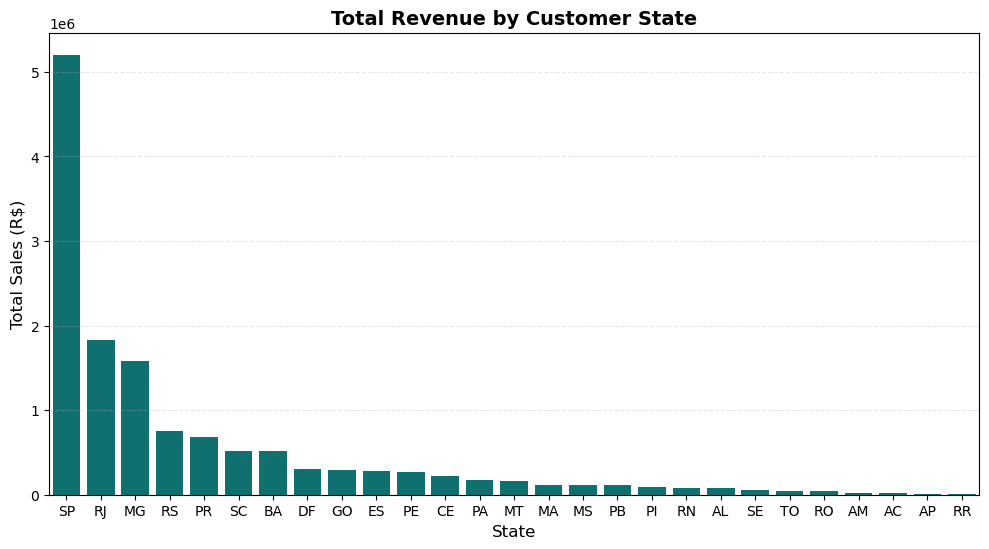

  customer_state  total_sales  percentage
0             SP   5202955.05   38.280543
1             RJ   1824092.67   13.420692
2             MG   1585308.03   11.663843
3             RS    750304.02    5.520333
4             PR    683083.76    5.025763


In [40]:
# First we need customer_state from customers and price from order items.
df_state = pd.merge(orders[['order_id', 'customer_id']], 
                  customers[['customer_id', 'customer_state']], 
                  on='customer_id')

df_state = pd.merge(df_state, 
                  order_items[['order_id', 'price']], 
                  on='order_id')

# We group by customer_state and sum prices.
state_revenue = df_state.groupby('customer_state').agg(
    total_sales=('price', 'sum')
).sort_values(by='total_sales', ascending=False).reset_index()

# We add a new percentage column for each state.
total_rev = state_revenue['total_sales'].sum()
state_revenue['percentage'] = (state_revenue['total_sales'] / total_rev) * 100

# Plot Total Revenue by Customer State.
plt.figure(figsize=(12, 6))
sns.barplot(data=state_revenue, x='customer_state', y='total_sales', color='teal')

plt.title('Total Revenue by Customer State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Sales (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# Print the top 5 to show the percentage of revenue.
print(state_revenue.head())

The data reveals a high geographical concentration, with São Paulo (SP) alone accounting for 38.28% of total revenue. When combined with Rio de Janeiro (13.42%) and Minas Gerais (11.66%), these three states represent over 63% of the platform's sales. 

---
## 4. Delivery Performance Reliability
In this section, I analyze the average delivery time and the rate of late deliveries. 

**Key Objectives:**
* Calculate the actual delivery time in days.
* Measure the percentage of orders delivered after the estimated date.

In [12]:
# Date conversion to datetime.
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# We add new rows to calculate deliverty time and delay.
orders['actual_delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

# We calculate the delay and the mean delivery time.
delivered_orders = orders.dropna(subset=['order_delivered_customer_date'])
late_orders_count = delivered_orders[delivered_orders['delivery_delay'] > 0].shape[0]
late_percentage = (late_orders_count / len(delivered_orders)) * 100

print(f"Average Delivery Time: {delivered_orders['actual_delivery_time'].mean():.2f} days")
print(f"Percentage of Late Deliveries: {late_percentage:.2f}%")

# We analyze the orders that weren't delivered.
order_status_counts = orders['order_status'].value_counts()
non_delivered = order_status_counts[order_status_counts.index != 'delivered']

print("\nOrders that did not reach the 'delivered' stage:")
print(non_delivered)

# Success rate 
success_rate = (order_status_counts['delivered'] / len(orders)) * 100
print(f"\nOverall Success Rate: {success_rate:.2f}%")

Average Delivery Time: 12.09 days
Percentage of Late Deliveries: 6.77%

Orders that did not reach the 'delivered' stage:
order_status
shipped        1107
canceled        625
unavailable     609
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64

Overall Success Rate: 97.02%


In [13]:
# Orders with 'delivered' status but no delivered date.
status_delivered_no_date = orders[(orders['order_status'] == 'delivered') & 
                                  (orders['order_delivered_customer_date'].isna())].shape[0]

# Orders with delivered date but no delivered status.
date_no_status_delivered = orders[(orders['order_status'] != 'delivered') & 
                                  (orders['order_delivered_customer_date'].notna())].shape[0]

print(f"Inconsistency 1 (Delivered status but no date): {status_delivered_no_date}")
print(f"Inconsistency 2 (Has date but status not 'delivered'): {date_no_status_delivered}")

Inconsistency 1 (Delivered status but no date): 8
Inconsistency 2 (Has date but status not 'delivered'): 6


The average delivery time is 12.09 days, with 6.77% of orders experiencing a delay relative to the estimated date. The platform maintains a high success rate, with 97.02% of orders successfully reaching their destination. A minor inconsistency was identified in 14 orders (0.01% of the dataset) where the 'delivered' status did not match the availability of delivery dates. However, this is statistically insignificant and does not affect the overall results.

---
## 5. Delivery Delays vs. Customer Satisfaction
We will investigate how delays translate into customer dissatisfaction. By crossing shipping data with review scores, we aim to measure the "penalty" that a late delivery imposes on the company's reputation.

**Key Objectives:**
* Merge the shipping performance data with customer review scores.
* Contrast the average review score of "On-Time" vs. "Late" deliveries.

In [38]:
#First we merge the orders dataframe with reviews on order ID.
df_satisfaction=pd.merge(orders,order_reviews[['order_id','review_score']], on='order_id')

delivered_only = df_satisfaction.dropna(subset=['delivery_delay']).copy()
delivered_only['is_late'] = delivered_only['delivery_delay'] > 0

#We calculate the mean value of the mean of the review score for products with and without delay.
avg_scores = delivered_only.groupby('is_late')['review_score'].mean().reset_index()

avg_scores['is_late'] = avg_scores['is_late'].map({True: 'Late', False: 'On-Time'})
avg_scores.columns = ['Delivery Status', 'Average Review Score']

print("Summary of Satisfaction by Delivery Performance:")
print(avg_scores.to_string(index=False))


Summary of Satisfaction by Delivery Performance:
Delivery Status  Average Review Score
        On-Time              4.289842
           Late              2.271139


Orders delivered on-time maintain a high satisfaction level (4.29 stars), whereas late deliveries suffer a massive penalty, dropping the average score to 2.27 stars. This represents a ~49% decrease in customer satisfaction due to shipping delays.

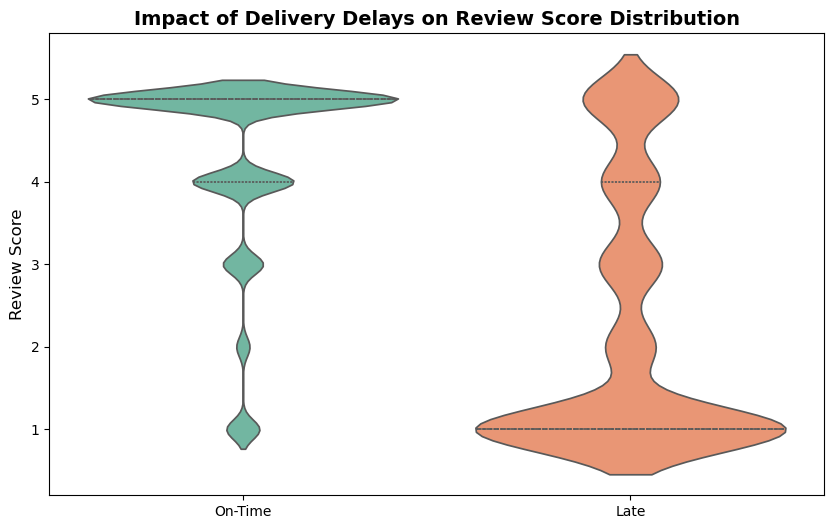

In [47]:
#To see the distribution more clearly we use a violin plot.
plt.figure(figsize=(10, 6))

sns.violinplot(data=delivered_only, x='is_late', y='review_score', 
               hue='is_late', palette='Set2', inner='quartile', legend=False)

plt.title('Impact of Delivery Delays on Review Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel(None)
plt.ylabel('Review Score', fontsize=12)
plt.xticks([0, 1], ['On-Time', 'Late'])
plt.show()

The plot shows a high density of 1-star reviews for delayed orders, whereas on-time deliveries are heavily clustered around 5-star ratings.

In [ ]:
#We will perform a t-test to confirm that delays affect user reviews.
from scipy import stats

score_ontime = delivered_only[delivered_only['is_late'] == False]['review_score']
score_late = delivered_only[delivered_only['is_late'] == True]['review_score']

t_statistic, p_value = stats.ttest_ind(score_ontime, score_late, equal_var=False)

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4e}")


T-statistic: 100.9659
P-value: 0.0000e+00


The t-test confirms with extreme statistical significance (p < 0.001, T=100.9) that delivery delays affect user reviews.

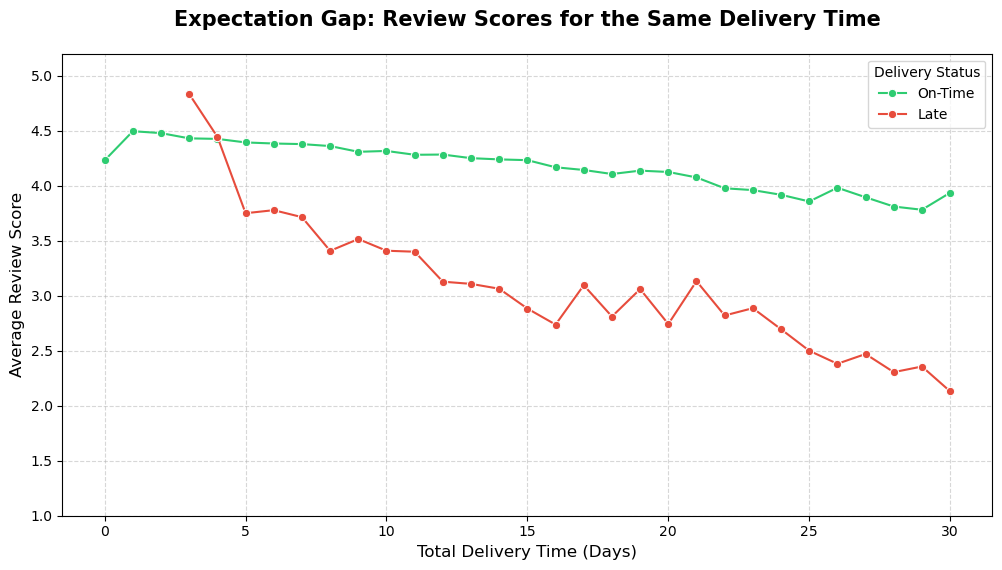

In [65]:
# We compare review scores for orders with the same total delivery time to isolate the 'Expectation Gap'. 
# This reveals how much a broken promise (Late) affects satisfaction compared to meeting a deadline (On-Time).

general_comparison = delivered_only.groupby(['actual_delivery_time', 'is_late'])['review_score'].mean().reset_index()

plot_data = general_comparison[general_comparison['actual_delivery_time'] <= 30].copy()
plot_data['Delivery Status'] = plot_data['is_late'].map({False: 'On-Time', True: 'Late'})

plt.figure(figsize=(12, 6))

sns.lineplot(data=plot_data, 
             x='actual_delivery_time', y='review_score', 
             hue='Delivery Status', 
             hue_order=['On-Time', 'Late'],
             marker='o', 
             palette={'On-Time': '#2ecc71', 'Late': '#e74c3c'},
             )

plt.title('Expectation Gap: Review Scores for the Same Delivery Time', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Total Delivery Time (Days)', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.ylim(1, 5.2)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The plot illustrates the impact of unfulfilled delivery expectations on user satisfaction. Also, we observe that even for on-time deliveries, satisfaction decreases over time, showing that speed remains a critical factor for user experience, regardless of whether the deadline was met. An anomaly is observed at the 3 and 4-day mark, where late orders show higher average reviews than on-time orders; this is likely due to a limited sample size for delayed deliveries in such a short timeframe and suggests that absolute speed may temporarily mitigate the negative effect of a delay. 

In [ ]:
#We are going to check the anomaly for fast deliveries.

counts_check = delivered_only.groupby(['actual_delivery_time', 'is_late'])['review_score'].agg(['mean', 'count']).reset_index()

print(counts_check[counts_check['actual_delivery_time'] <= 5])

   actual_delivery_time  is_late      mean  count
0                   0.0    False  4.230769     13
1                   1.0    False  4.495547   1572
2                   2.0    False  4.478330   3161
3                   3.0    False  4.430541   3844
4                   3.0     True  4.833333      6
5                   4.0    False  4.425757   4822
6                   4.0     True  4.444444      9
7                   5.0    False  4.393536   5786
8                   5.0     True  3.750000     16


Lastly, we confirm that the anomaly observed at days 3 and 4 is caused by a limited sample size. There were only 6 and 9 late deliveries respectively, compared to more than 3,000 deliveries arriving on time. This confirms that those specific data points are not statistically representative.